# Lab 5: 2D (Bivariate) Data Visualization

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from pandas.plotting import scatter_matrix
from scipy.stats import pearsonr

# Load data
df = pd.read_csv('Datasets/nyc_taxi_trip_duration.csv', parse_dates=['pickup_datetime', 'dropoff_datetime'])
df['trip_duration_min'] = df['trip_duration'] / 60  # Convert duration to minutes
print(df.head(), df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  729322 non-null  object        
 1   vendor_id           729322 non-null  int64         
 2   pickup_datetime     729322 non-null  datetime64[ns]
 3   dropoff_datetime    729322 non-null  datetime64[ns]
 4   passenger_count     729322 non-null  int64         
 5   pickup_longitude    729322 non-null  float64       
 6   pickup_latitude     729322 non-null  float64       
 7   dropoff_longitude   729322 non-null  float64       
 8   dropoff_latitude    729322 non-null  float64       
 9   store_and_fwd_flag  729322 non-null  object        
 10  trip_duration       729322 non-null  int64         
 11  trip_duration_min   729322 non-null  float64       
dtypes: datetime64[ns](2), float64(5), int64(3), object(2)
memory usage: 66.8+ MB
         

1 Scattered Plot Visualization

1.1 Basic Scatter Plot: trip_distance vs trip_duration_min

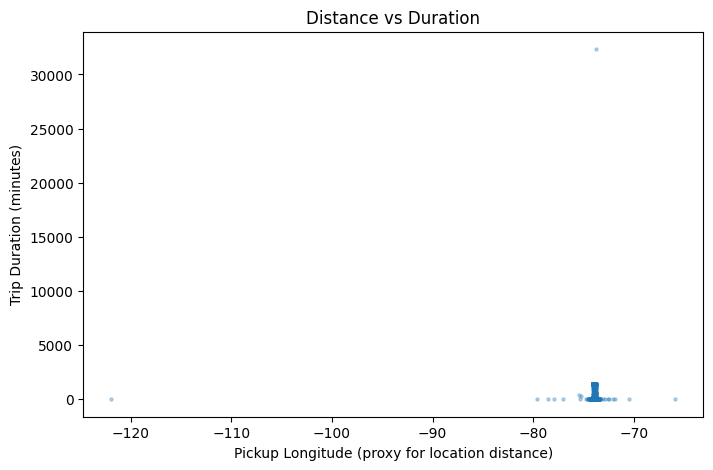

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['pickup_longitude'], df['trip_duration_min'], alpha=0.3, s=5)
plt.title('Distance vs Duration')
plt.xlabel('Pickup Longitude (proxy for location distance)')
plt.ylabel('Trip Duration (minutes)')
plt.show()


1.2 Bubble Chart

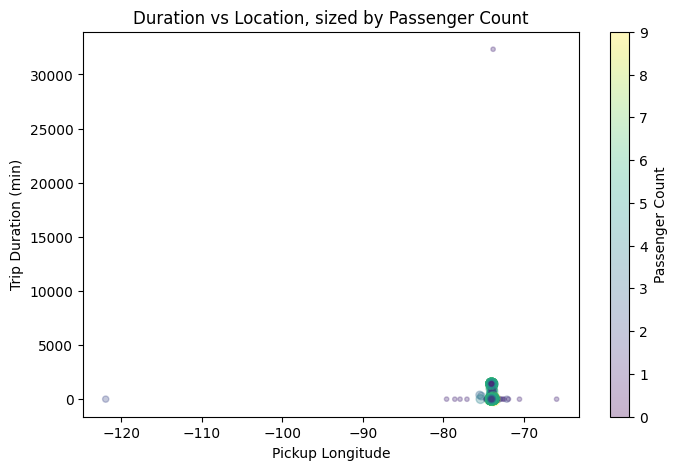

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df['pickup_longitude'], df['trip_duration_min'],
            s=df['passenger_count']*10,
            alpha=0.3, c=df['passenger_count'], cmap='viridis')
plt.title('Duration vs Location, sized by Passenger Count')
plt.xlabel('Pickup Longitude')
plt.ylabel('Trip Duration (min)')
plt.colorbar(label='Passenger Count')
plt.show()


1.3 Grouped Scatter

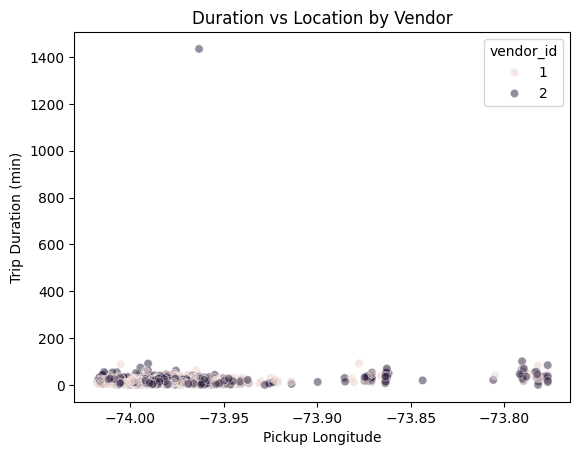

In [24]:
sns.scatterplot(x='pickup_longitude', y='trip_duration_min',
                hue='vendor_id', data=df.sample(2000), alpha=0.5)
plt.title('Duration vs Location by Vendor')
plt.xlabel('Pickup Longitude')
plt.ylabel('Trip Duration (min)')
plt.show()


1.4 Regression Line

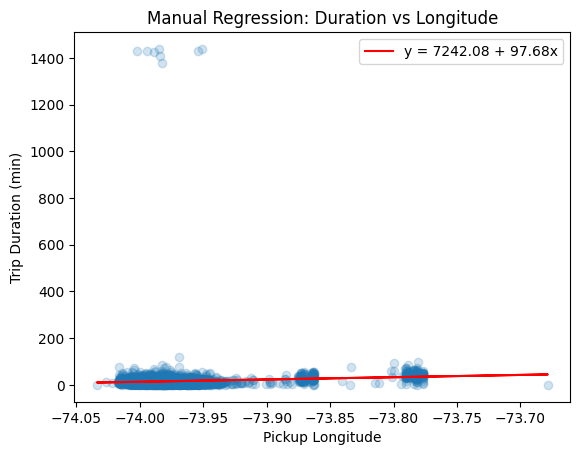

In [25]:
sample = df.sample(5000)
x = sample[['pickup_longitude']].values
y = sample[['trip_duration_min']].values

Xbar, Ybar = x.mean(), y.mean()
b1 = ((x - Xbar)*(y - Ybar)).sum() / ((x - Xbar)**2).sum()
b0 = Ybar - b1 * Xbar

plt.scatter(x, y, alpha=0.2)
plt.plot(x, b0 + b1*x, color='red', label=f'y = {b0:.2f} + {b1:.2f}x')
plt.title('Manual Regression: Duration vs Longitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Trip Duration (min)')
plt.legend()
plt.show()


1.5 Regression via Sklearn

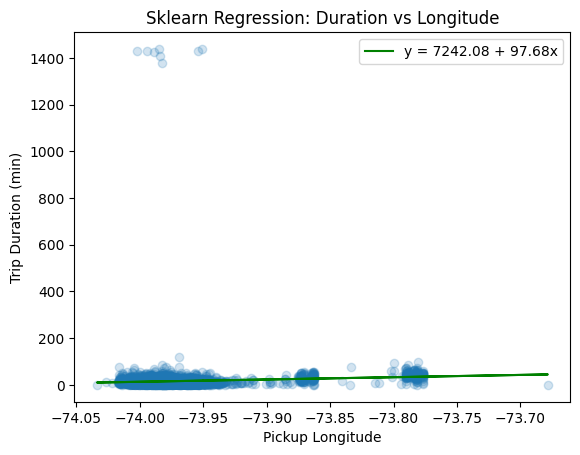

In [26]:
model = LinearRegression().fit(x, y)
yp = model.predict(x)
plt.scatter(x, y, alpha=0.2)
plt.plot(x, yp, color='green',
         label=f'y = {model.intercept_[0]:.2f} + {model.coef_[0][0]:.2f}x')
plt.title('Sklearn Regression: Duration vs Longitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Trip Duration (min)')
plt.legend()
plt.show()


1.6 Scattered Matrix

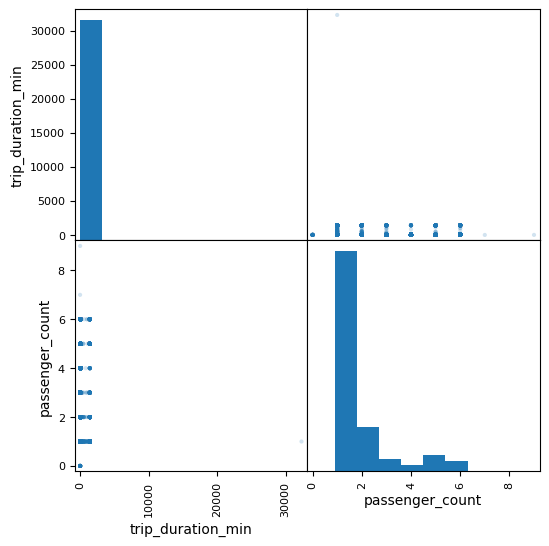

In [27]:
scatter_matrix(df[['trip_duration_min','passenger_count']], alpha=0.2, figsize=(6,6))
plt.show()


1.7 Pair Plot

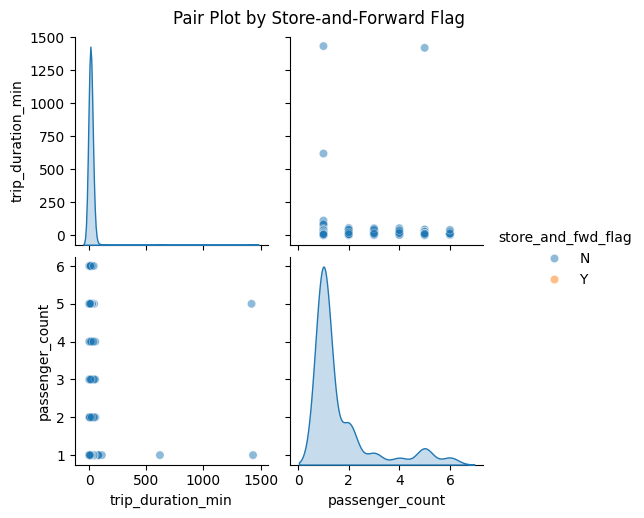

In [28]:
sns.pairplot(df.sample(1000),
             vars=['trip_duration_min','passenger_count'],
             hue='store_and_fwd_flag', plot_kws={'alpha':0.5})
plt.suptitle('Pair Plot by Store-and-Forward Flag', y=1.02)
plt.show()


2 Line Chart Visualization

In [29]:
df['pickup_date'] = df['pickup_datetime'].dt.date
daily = df.groupby('pickup_date').agg(
    avg_duration=('trip_duration_min', 'mean'),
    trip_count=('id', 'count'),
    total_passengers=('passenger_count', 'sum')
).reset_index()


2.1 Basic Line: average trip duration over time

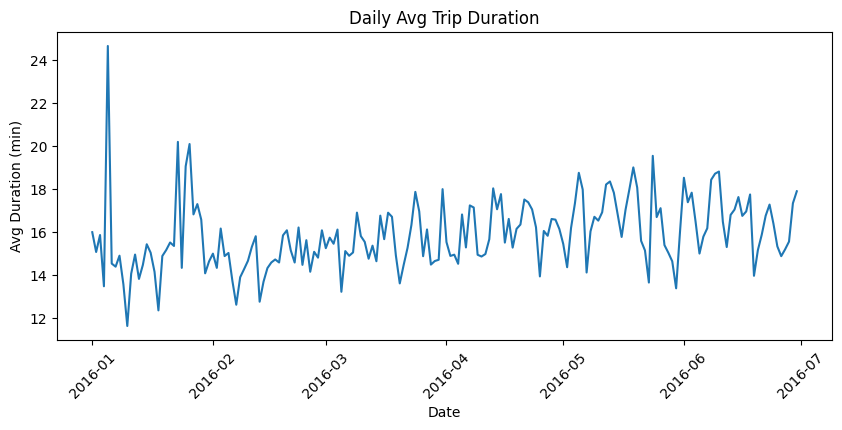

In [30]:
plt.figure(figsize=(10,4))
plt.plot(daily['pickup_date'], daily['avg_duration'])
plt.title('Daily Avg Trip Duration')
plt.xlabel('Date')
plt.ylabel('Avg Duration (min)')
plt.xticks(rotation=45)
plt.show()


2.2 Multi-Series: add trip_count

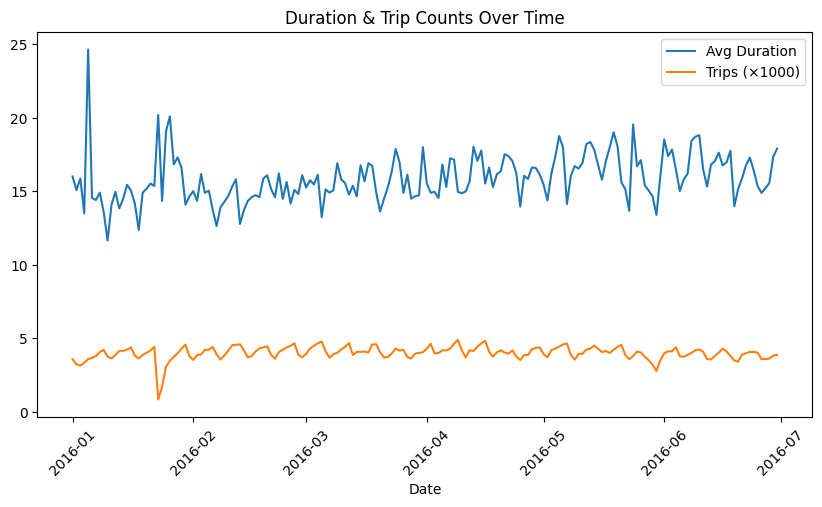

In [31]:
plt.figure(figsize=(10,5))
plt.plot(daily['pickup_date'], daily['avg_duration'], label='Avg Duration')
plt.plot(daily['pickup_date'], daily['trip_count']/1000, label='Trips (×1000)')
plt.title('Duration & Trip Counts Over Time')
plt.xlabel('Date')
plt.legend()
plt.xticks(rotation=45)
plt.show()


2.3 Stacked Area: trip counts & total passengers

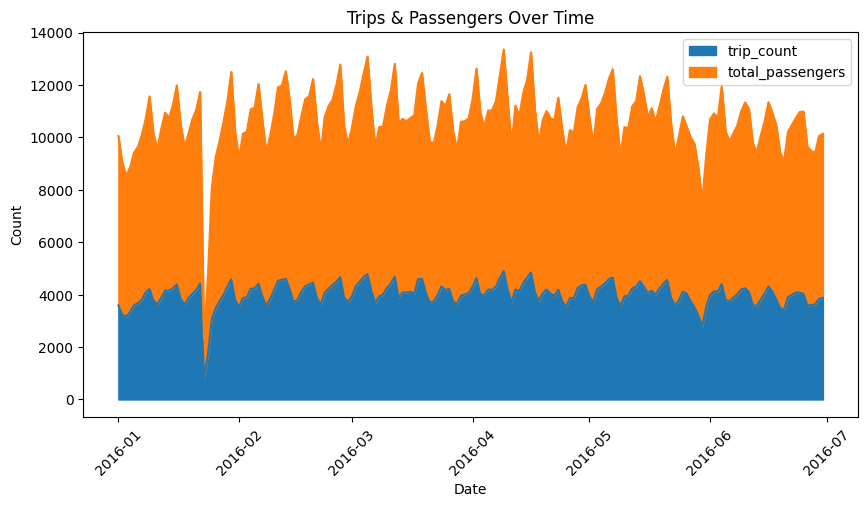

In [32]:
daily.set_index('pickup_date')[['trip_count','total_passengers']].plot.area(figsize=(10,5))
plt.title('Trips & Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


2.4 Smoothed Line (7-day rolling)

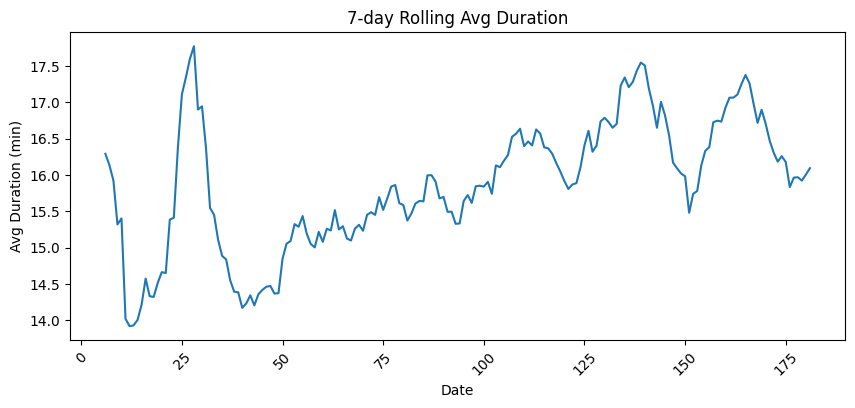

In [33]:
plt.figure(figsize=(10,4))
daily['avg_duration'].rolling(7).mean().plot()
plt.title('7‑day Rolling Avg Duration')
plt.xlabel('Date')
plt.ylabel('Avg Duration (min)')
plt.xticks(rotation=45)
plt.show()


2.5 Step Chart: daily trip count

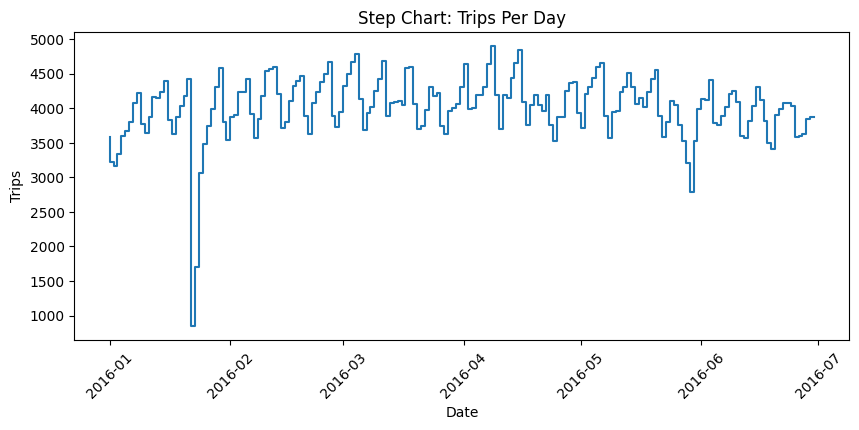

In [34]:
plt.figure(figsize=(10,4))
plt.step(daily['pickup_date'], daily['trip_count'])
plt.title('Step Chart: Trips Per Day')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.xticks(rotation=45)
plt.show()


3 Heatmap Visualizations

3.1 Correlation Matrix

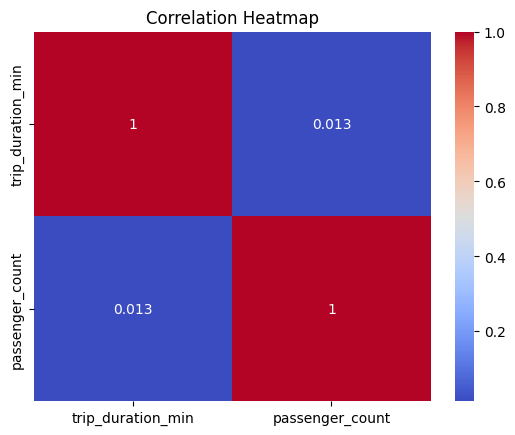

In [35]:
num = ['trip_duration_min','passenger_count']
corr = df[num].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


3.2 Custom Pearson Correlation

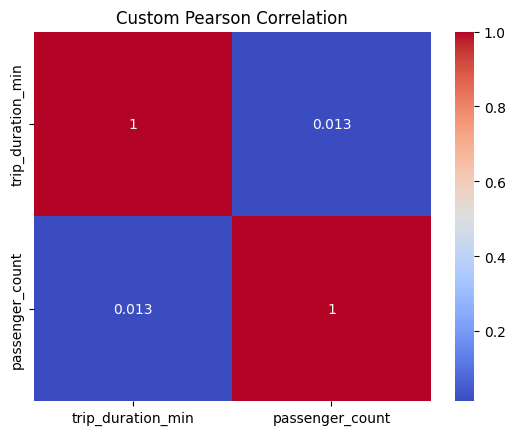

In [36]:
m = np.array([[pearsonr(df[a],df[b])[0] for b in num] for a in num])
sns.heatmap(m, annot=True, xticklabels=num, yticklabels=num, cmap='coolwarm')
plt.title('Custom Pearson Correlation')
plt.show()


3.3 Calendar Heatmap: trips by week/day

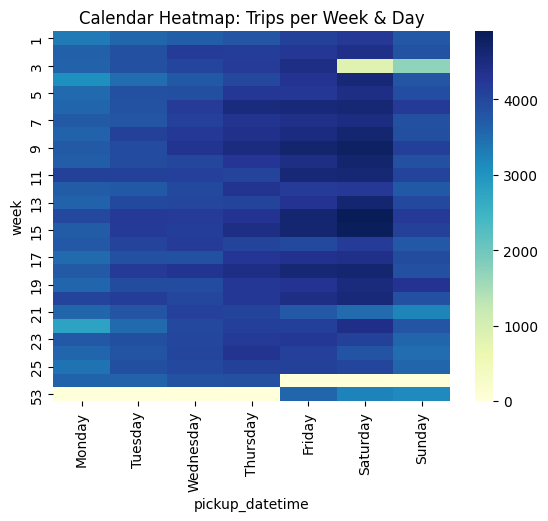

In [37]:
weekly = df.groupby([df['pickup_datetime'].dt.isocalendar().week,
                     df['pickup_datetime'].dt.day_name()]).size().unstack(fill_value=0)
days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.heatmap(weekly[days], cmap='YlGnBu')
plt.title('Calendar Heatmap: Trips per Week & Day')
plt.show()


3.4 Clustered Heatmap

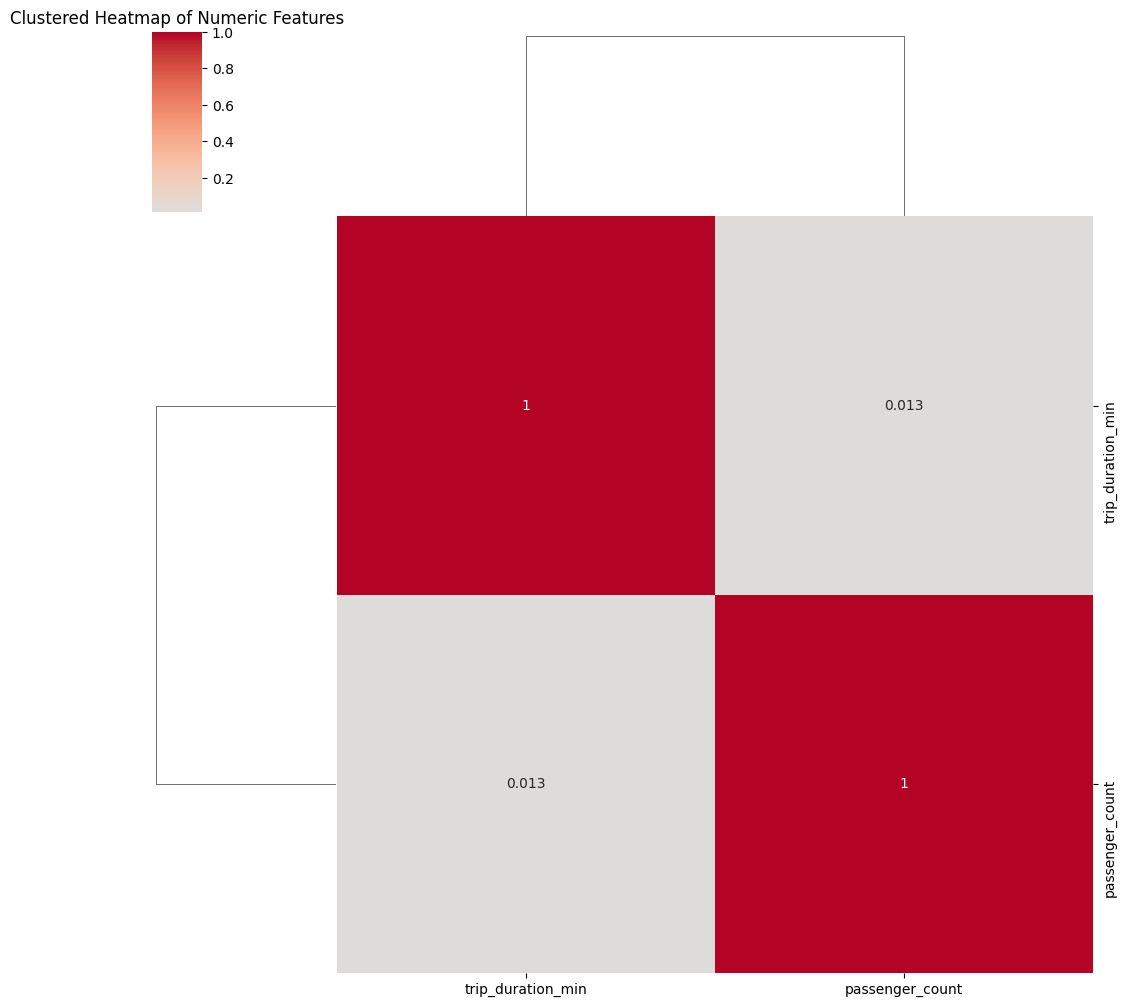

In [38]:
sns.clustermap(corr, annot=True, center=0, cmap='coolwarm')
plt.title('Clustered Heatmap of Numeric Features')
plt.show()


3.5 Non‑Spatial “Geographic” Heatmap: vendor_id counts

In [39]:
import plotly.express as px

vc = df['vendor_id'].value_counts().reset_index()
vc.columns = ['vendor_id', 'count']

fig = px.bar(vc, x='vendor_id', y='count', text='count',
             title='Trips by Vendor ID')
fig.show()
